In [1173]:
import os
import math
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchvision

Image we're using:

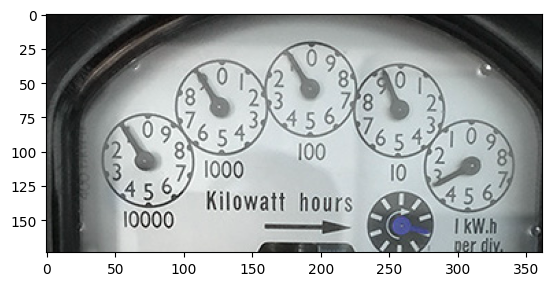

In [1174]:
img = cv2.imread('dialmeter1.jpg')
plt.imshow(img)

There's 36 degrees between each number. So, depending on the angle of the pointer, we can get the value.  
- First, third, and fifth dials: CW
    - Value (degrees):
        - 0: [90, 54)
        - 1: [54, 18)
        - 2: [18, 342)
        - 3: [342, 306)
        - 4: [306, 270)
        - 5: [270, 234)
        - 6: [234, 198)
        - 7: [198, 162)
        - 8: [162, 126)
        - 9: [126, 90)
- Second and fourth dials: CCW  
    - Value (degrees):
        - 0: [90, 126)
        - 1: [126, 162)
        - 2: [162, 198)
        - 3: [198, 234)
        - 4: [234, 270)
        - 5: [270, 306)
        - 6: [306, 342)
        - 7: [342, 18)
        - 8: [18, 54)
        - 9: [54, 90)

(( these are supposed to be flipped ))


In [1175]:
# value ranges for first, third, and fifth dials
CCW_value_ranges = {
    0: [90, 126],
    1: [126, 162],
    2: [162, 198],
    3: [198, 234],
    4: [234, 270],
    5: [270, 306],
    6: [306, 342],
    7: [342, 18],
    8: [18, 54],
    9: [54, 90]
}

# value ranges for second and fourth dials
CW_value_ranges = {
    0: [90, 54],
    1: [54, 18],
    2: [18, 342],
    3: [342, 306],
    4: [306, 270],
    5: [270, 234],
    6: [234, 198],
    7: [198, 162],
    8: [162, 126],
    9: [126, 90]
}

Preprocess the image

In [1176]:
def Preprocess(image):
    # tilt correction
    # gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # edges = cv2.Canny(gray, 50, 150, apertureSize=3)
    # lines = cv2.HoughLines(edges, rho=1, theta=np.pi/180, threshold=100)
    # angle = np.mean([line[0][1] for line in lines])

    # height, width = image.shape[:2]
    # center = (width // 2, height // 2)
    # M = cv2.getRotationMatrix2D(center, -angle, 1.0)
    # rotated = cv2.warpAffine(image, M, (width, height), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    gaussian_gray = cv2.GaussianBlur(gray, (5, 5), 0)
    
    
    return gray, gaussian_gray
    


Find and outline the dials

In [1177]:
def DialDetector(image, gaussian_gray):

    # find the circles
    circles = cv2.HoughCircles(gaussian_gray, cv2.HOUGH_GRADIENT, dp=1, minDist=45, param1=200, param2=75, minRadius=0, maxRadius=0)
    # round all x, y, r values
    circles = np.uint16(np.around(circles))


    print("np array of circles (x, y, r)")
    print(circles)
    print(type(circles))
    # Sort the circles from left to right (smallest to largest x-value)
    print("\nnp array of circles (x, y, r): sorted")
    circles = circles[0][np.argsort(circles[:, :, 0])]
    print(circles)
    print(type(circles), "\n")
    
    # draw the circles
    for i in circles[0][:5]:
    # draws the outer part of the circle
        cv2.circle(image,(i[0],i[1]),i[2],(0,255,0),2)
    # draws the center of the circle
        cv2.circle(image,(i[0],i[1]),2,(0,0,255),3)
   
    return circles


In [1178]:
def DialValue(circles, gray, image):

    # i = 1, so we know what circle we are currently on for the CW/CCW value ranges
    i = 1
    for c in circles[0]:
        
        x, y, r = c[0], c[1], c[2]

        mask = np.zeros(gray.shape, dtype=np.uint8)
        cv2.circle(mask, (x, y), r, 255, -1)

        dial = cv2.bitwise_and(gray, gray, mask=mask)

        _, thresh = cv2.threshold(dial, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
        
        max_area = 0
        max_contour = None
        for contour in contours:
            area = cv2.contourArea(contour)
            if area > max_area:
                max_area = area
                max_contour = contour

        if max_contour is not None:
            rows, cols = gray.shape[:2]
            [vx,vy,x,y] = cv2.fitLine(max_contour, cv2.DIST_L2,0,0.01,0.01)
            lefty = int((-x*vy/vx)+y)
            righty = int(((cols-x)*vy/vx)+y)
            cv2.line(image,(cols-1,righty),(0,lefty),(255,0,0),2)

            angle = np.rad2deg(np.arctan2(-vy, vx)) - 180

            if angle < 0:
                angle += 360.0
            cv2.putText(image, str(int(angle)), (int(x) + 10,int(y)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
            print(f"Angle: {angle}")

            # getting the value of the angle pointer
            if (i % 2 == 0):
                for value, angle_range in CW_value_ranges.items():
                    if angle <= angle_range[0] and angle > angle_range[1]:
                        print("value: ", value)
                        break
            else:
                for value, angle_range in CCW_value_ranges.items():
                    if angle >= angle_range[0] and angle < angle_range[1]:
                        print("value: ", value)
                        break
            i += 1


np array of circles (x, y, r)
[[[ 74 106  35]
  [256  70  34]
  [128  66  34]
  [194  54  35]
  [306 114  32]]]
<class 'numpy.ndarray'>

np array of circles (x, y, r): sorted
[[[ 74 106  35]
  [128  66  34]
  [194  54  35]
  [256  70  34]
  [306 114  32]]]
<class 'numpy.ndarray'> 

Angle: [129.29037]
value:  1
Angle: [172.38768]
value:  7
Angle: [159.82826]
value:  1
Angle: [230.82584]
value:  6
Angle: [99.39139]
value:  0


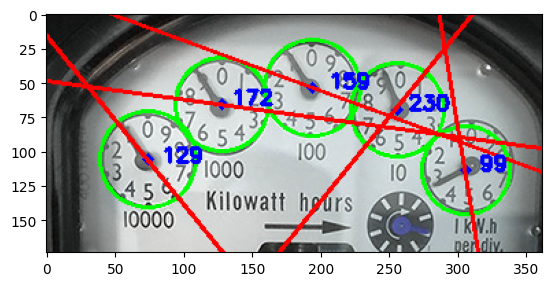

In [1179]:
gray, gaussian_gray = Preprocess(img)
dials = DialDetector(img, gaussian_gray)
value = DialValue(dials, gray, img)

plt.imshow(img)